In [1]:
import pandas as pd

df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
target = 'Survived'

X = df[features]
y = df[target]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")


Random Forest Accuracy: 81.01 %


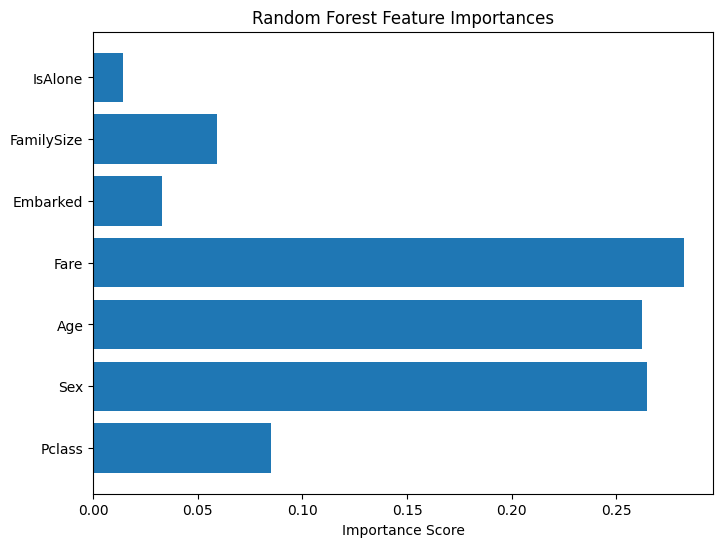

In [5]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importances")
plt.show()


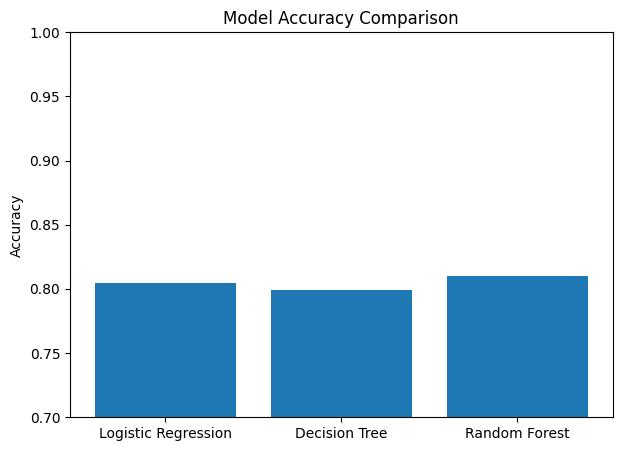

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Re-train models for fairness
logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

acc_log = accuracy_score(y_test, logreg.predict(X_test))
acc_tree = accuracy_score(y_test, tree.predict(X_test))

# Bar Chart
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [acc_log, acc_tree, rf_acc]

plt.figure(figsize=(7,5))
plt.bar(models, scores)
plt.ylim(0.7, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()
